# RAG on LangChain p2

First, let's revisit the steps in the RAG (Retrieval-Augmented Generation) flow.

1. **Indexing**: Relevant data is converted into vector representations and stored in a specialized database.
2. **Retrieval**: When a query is made, the system searches for the most relevant documents in the database.
3. **Augmentation**: The retrieved information is incorporated into the original prompt to provide additional context to the language model.
4. **Generation**: The language model generates a response based on both its prior knowledge and the newly retrieved information.

These steps can also be illustrated by the image below:

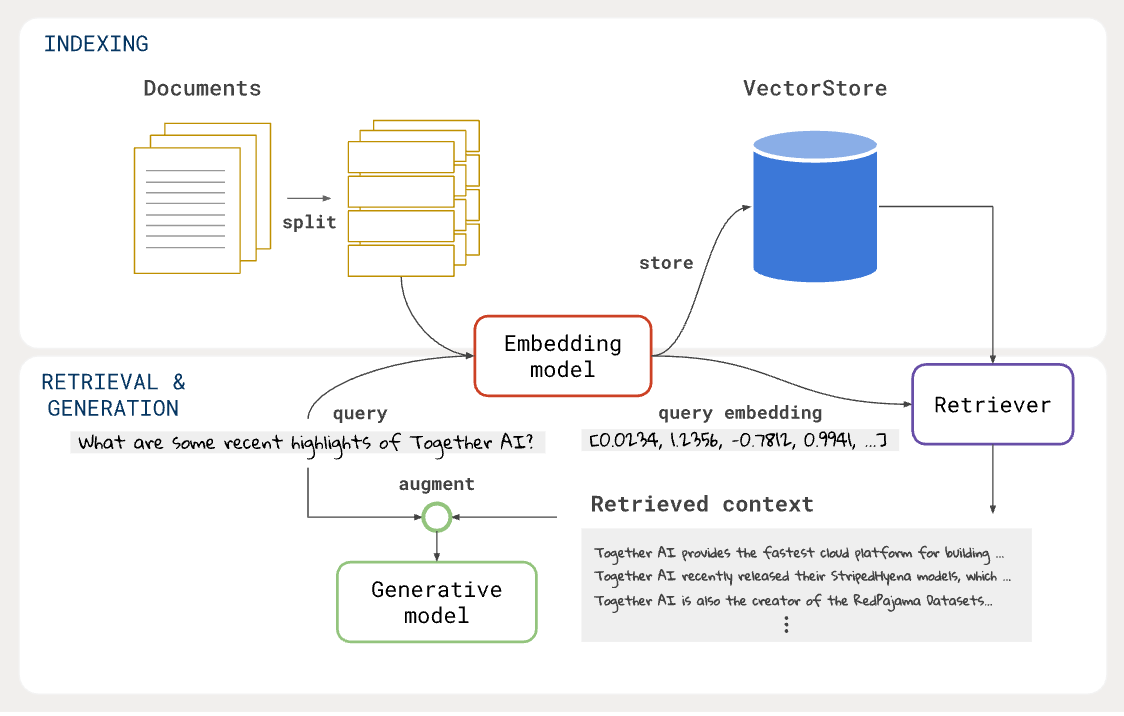

# Section 6. Retrieval

With the Vector Store defined, our goal now is: given a user query, identify which text fragments are contextually most similar to that query.

Next, we must retrieve these fragments and convert them back into text so they can be used as context for the response.

In [4]:
!pip install -qU dotenv langchain_openai langchain-google-genai -U wikipedia -U numexpr langchain_community langgraph DateTime pypdf langchain-chroma langchain_nvidia_ai_endpoints langchain_openrouter langsmith
!wget -r -np -nH --cut-dirs=3 -R "index.html*" https://github.com/langchain-ai/langchain/raw/master/docs/docs/example_data/

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 7.0 MB/s eta 0:00:00
--2026-04-26 15:58:23--  https://github.com/langchain-ai/langchain/raw/master/docs/docs/example_data/
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-04-26 15:58:23 ERROR 404: Not Found.



In [ ]:
from IPython.display import Markdown
import getpass
import os

from dotenv import load_dotenv, find_dotenv
_ = load_dotenv(find_dotenv()) # read local .env file

In [7]:
from google.colab import userdata
import os

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_API_KEY"] = userdata.get('LANGCHAIN_API_KEY')
os.environ["LANGCHAIN_PROJECT"] = "LLM Class"

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
from langchain_openrouter import ChatOpenRouter
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from google.colab import userdata

def get_model_name(model_name, temperature=0):
    if model_name == "gemini": # https://ai.google.dev/gemini-api/docs/rate-limits?hl=pt-br
        if "GOOGLE_API_KEY" not in os.environ: # https://ai.google.dev/gemini-api/docs/api-key
            os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')
        llm = ChatGoogleGenerativeAI(
            # model="gemini-2.5-pro", # max 50 / dia
            model="gemini-2.5-flash", # max 1500 / dia
            temperature=temperature,
        )
    elif model_name == "openai":  # https://platform.openai.com
        if "OPENAI_API_KEY" not in os.environ:
            os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
        llm = ChatOpenAI(
            model="gpt-4o-mini",
            temperature=temperature,
        )
    elif model_name == "openrouter": # https://openrouter.ai/workspaces/default/
        if "OPENROUTER_API_KEY" not in os.environ:
            os.environ["OPENROUTER_API_KEY"] = userdata.get('OPENROUTER_API_KEY')

        llm = ChatOpenRouter(
            model="openrouter/free",
            api_key=os.environ["OPENROUTER_API_KEY"],
            temperature=temperature,
        )
    elif model_name == "nvidia": # https://build.nvidia.com/explore/discover
       if "NVIDIA_API_KEY" not in os.environ:
           os.environ["NVIDIA_API_KEY"] = userdata.get('NVIDIA_API_KEY')
       llm = ChatNVIDIA(
           model="meta/llama-4-maverick-17b-128e-instruct",
           api_key=os.environ["NVIDIA_API_KEY"],
           temperature=temperature,
       )

    return llm

llm = get_model_name('nvidia')
resp = llm.invoke("Olá")
print(resp.content)

Olá! Como posso ajudar você hoje?


First, let's run the Indexing steps again.

In [ ]:
from langchain_community.document_loaders import PyPDFLoader
loader = PyPDFLoader("nke-10k-2023.pdf")
docs = loader.load()

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,  # chunk size (characters)
    chunk_overlap=200,  # chunk overlap (characters)
    add_start_index=True,  # track index in original document
)
all_splits = text_splitter.split_documents(docs)

for i, doc in enumerate(all_splits):
    doc.metadata["chunk_id"] = f"nike_chunk_{i}"

print(f"Split PDF into {len(all_splits)} sub-documents.")
print("Example chunk id:", all_splits[0].metadata["chunk_id"])

Split PDF into 516 sub-documents.
Example chunk id: nike_chunk_0


In [ ]:
# from langchain_openai import OpenAIEmbeddings
# embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
from langchain_google_genai import GoogleGenerativeAIEmbeddings
embeddings = GoogleGenerativeAIEmbeddings(model="models/embedding-001")

In [ ]:
import time
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_nvidia_ai_endpoints import NVIDIAEmbeddings

embeddings = NVIDIAEmbeddings(
    model="nvidia/nv-embed-v1",
    api_key=os.environ["NVIDIA_API_KEY"]
)
vector_store = InMemoryVectorStore(embeddings)

all_ids = []

for i in range(0, len(all_splits), 20):
    batch = all_splits[i:i + 20]

    while True:
        try:
            ids = vector_store.add_documents(documents=batch)
            all_ids.extend(ids)
            print(f"Batch {i // 20 + 1}: {len(ids)} documents added")
            break
        except Exception as e:
            if "429" in str(e) or "RESOURCE_EXHAUSTED" in str(e):
                print("RESOURCE_EXHAUSTED. Waiting 30 segundos...")
                time.sleep(30)
            else:
                raise

print(f"Added {len(all_ids)} documents to the vector store.")

Batch 1: 20 documents added
Batch 2: 20 documents added
Batch 3: 20 documents added
Batch 4: 20 documents added
Batch 5: 20 documents added
Batch 6: 20 documents added
Batch 7: 20 documents added
Batch 8: 20 documents added
Batch 9: 20 documents added
Batch 10: 20 documents added
Batch 11: 20 documents added
Batch 12: 20 documents added
Batch 13: 20 documents added
Batch 14: 20 documents added
Batch 15: 20 documents added
Batch 16: 20 documents added
Batch 17: 20 documents added
Batch 18: 20 documents added
Batch 19: 20 documents added
Batch 20: 20 documents added
Batch 21: 20 documents added
Batch 22: 20 documents added
Batch 23: 20 documents added
Batch 24: 20 documents added
Batch 25: 20 documents added
Batch 26: 16 documents added
Added 516 documents to the vector store.


## 6.1 Vector Store Retrieval

We can use the vector store to retrieve the most relevant documents for a given query. This is done by embedding the query and finding the closest vectors in the vector store. LangChain provides several methods for retrieval, including:

### Similarity Search

* Performs the search by returning the documents most similar to the query string based on vector similarity.

### Maximum Marginal Relevance

* Aims to balance relevance with diversity in the returned results, avoiding highly redundant documents.

The examples below focus on dense retrieval first. After that, we will complement it with BM25 and a simple mixed retrieval strategy.

In [ ]:
question = "How were margins impacted in 2023?"
results = vector_store.similarity_search(question,k=3)
for doc in results:
    print('\n', doc.page_content, '\n')


 Commission on July 21, 2022.
CURRENT ECONOMIC CONDITIONS AND MARKET DYNAMICS
• Consumer Spending: Our fiscal 2023 growth in Revenues reflects strong demand for our products despite ongoing uncertainty in the global economy. We will
continue to closely monitor macroeconomic conditions, including potential impacts of inflation and rising interest rates on consumer behavior.
• Inflationary Pressures: Inflationary pressures, including higher product input, freight and logistics costs negatively impacted gross margin for fiscal 2023. The
strategic pricing actions we have taken partially offset the impacts of these higher costs.
• Supply Chain Volatility: Supply chain challenges, macroeconomic conditions and the impact of the COVID-19 pandemic on the manufacturing of our product
disrupted the flow of seasonal product in fiscal 2022 and the first quarter of fiscal 2023, resulting in elevated inventory levels at the end of the first quarter of fiscal 


 Table of Contents
GROSS MARGIN
FISCAL

### 1. `similarity_search_with_score`

* **What it does:** Returns the most similar documents to your query **along with their similarity scores.**
* **Typical use:** When you need to know how similar each document is to the query.
* **Return:** `[(doc1, score1), (doc2, score2), ...]`
* **Basis:** Search based on embedding similarity (e.g., cosine similarity).


In [ ]:
# Note that providers implement different scores; the score here
# is a distance metric that varies inversely with similarity.

results = vector_store.similarity_search_with_score("How were margins impacted in 2023?", k=3)
for doc, score in results:
    print(f"\nScore: {score}")
    print(doc.page_content, '\n')


Score: 0.41310302559833856
Commission on July 21, 2022.
CURRENT ECONOMIC CONDITIONS AND MARKET DYNAMICS
• Consumer Spending: Our fiscal 2023 growth in Revenues reflects strong demand for our products despite ongoing uncertainty in the global economy. We will
continue to closely monitor macroeconomic conditions, including potential impacts of inflation and rising interest rates on consumer behavior.
• Inflationary Pressures: Inflationary pressures, including higher product input, freight and logistics costs negatively impacted gross margin for fiscal 2023. The
strategic pricing actions we have taken partially offset the impacts of these higher costs.
• Supply Chain Volatility: Supply chain challenges, macroeconomic conditions and the impact of the COVID-19 pandemic on the manufacturing of our product
disrupted the flow of seasonal product in fiscal 2022 and the first quarter of fiscal 2023, resulting in elevated inventory levels at the end of the first quarter of fiscal 


Score: 0.410

### 2. `similarity_search_by_vector`

* **What it does:** Allows searching for documents based on a custom embedding vector, instead of a text string.
* **Typical use:** When you already have the query vector (e.g., from an external model).
* **Returns:** `[doc1, doc2, ...]`
* **Basis:** Similarity with the provided vector.


In [ ]:
embedding = embeddings.embed_query("How were margins impacted in 2023?")

results = vector_store.similarity_search_by_vector(embedding, k=3)
for doc in results:
    print('\n', doc.page_content, '\n')


 Commission on July 21, 2022.
CURRENT ECONOMIC CONDITIONS AND MARKET DYNAMICS
• Consumer Spending: Our fiscal 2023 growth in Revenues reflects strong demand for our products despite ongoing uncertainty in the global economy. We will
continue to closely monitor macroeconomic conditions, including potential impacts of inflation and rising interest rates on consumer behavior.
• Inflationary Pressures: Inflationary pressures, including higher product input, freight and logistics costs negatively impacted gross margin for fiscal 2023. The
strategic pricing actions we have taken partially offset the impacts of these higher costs.
• Supply Chain Volatility: Supply chain challenges, macroeconomic conditions and the impact of the COVID-19 pandemic on the manufacturing of our product
disrupted the flow of seasonal product in fiscal 2022 and the first quarter of fiscal 2023, resulting in elevated inventory levels at the end of the first quarter of fiscal 


 Table of Contents
GROSS MARGIN
FISCAL

### 3. `max_marginal_relevance_search` (MMR)

* **What it does:** Returns documents that are both relevant to the query and diverse among themselves.
* **Typical use:** Avoid redundancy in results, promoting informative coverage.
* **Returns:** `[doc1, doc2, ...]`
* **How it works:** Balances similarity to the query and diversity among documents.


In [ ]:
results = vector_store.max_marginal_relevance_search("How were margins impacted in 2023?",k=3, fetch_k=3)
for doc in results:
     print('\n', doc.page_content, '\n')


 Commission on July 21, 2022.
CURRENT ECONOMIC CONDITIONS AND MARKET DYNAMICS
• Consumer Spending: Our fiscal 2023 growth in Revenues reflects strong demand for our products despite ongoing uncertainty in the global economy. We will
continue to closely monitor macroeconomic conditions, including potential impacts of inflation and rising interest rates on consumer behavior.
• Inflationary Pressures: Inflationary pressures, including higher product input, freight and logistics costs negatively impacted gross margin for fiscal 2023. The
strategic pricing actions we have taken partially offset the impacts of these higher costs.
• Supply Chain Volatility: Supply chain challenges, macroeconomic conditions and the impact of the COVID-19 pandemic on the manufacturing of our product
disrupted the flow of seasonal product in fiscal 2022 and the first quarter of fiscal 2023, resulting in elevated inventory levels at the end of the first quarter of fiscal 


 Table of Contents
GROSS MARGIN
FISCAL

### Summary:

### 1. `similarity_search_with_score`

* **What it does:** Returns the documents most similar to your query along with their similarity scores.
* **Typical use:** When you need to know how similar each document is to the query.
* **Returns:** `[(doc1, score1), (doc2, score2), ...]`
* **Basis:** Search based on embedding similarity (e.g., cosine similarity).

---

### 2. `similarity_search_by_vector`

* **What it does:** Allows you to search for documents using a custom embedding vector instead of a text string.
* **Typical use:** When you already have the query vector (e.g., from an external model).
* **Returns:** `[doc1, doc2, ...]`
* **Basis:** Similarity with the provided vector.

---

### 3. `max_marginal_relevance_search` (MMR)

* **What it does:** Returns documents that are relevant to the query and also diverse among themselves.
* **Typical use:** To avoid redundancy in results and promote informative coverage.
* **Returns:** `[doc1, doc2, ...]`
* **How it works:** Balances similarity to the query with diversity among documents.

---
Next, we will add a sparse retriever with BM25 and combine it with dense retrieval through a lightweight fusion strategy.

## 6.2 Mixed Retrieval: BM25 + Query Expansion

Dense retrieval is excellent at semantic similarity, but exact keyword matching can still matter. BM25 is a classic sparse retrieval method that gives more weight to exact query terms.

A practical pattern is to combine both views:

1. **Dense retrieval** for semantic similarity.
2. **BM25** for lexical precision.
3. **Query expansion** to search with a few reformulations of the same question.
4. **Rank fusion** to merge the candidate lists into a final ranking.

In [ ]:
from langchain_community.retrievers import BM25Retriever

dense_retriever = vector_store.as_retriever(search_kwargs={"k": 3})

bm25_retriever = BM25Retriever.from_documents(all_splits)
bm25_retriever.k = 3


def preview_docs(docs, max_chars=220):
    for i, doc in enumerate(docs, start=1):
        chunk_id = doc.metadata.get("chunk_id", f"doc_{i}")
        snippet = doc.page_content[:max_chars].replace("\n", " ")
        print(f"{i}. {chunk_id}")
        print(snippet)
        print("-" * 80)


question = "How were margins impacted in 2023?"

print("Dense retrieval")
preview_docs(dense_retriever.invoke(question))

print("\nBM25 retrieval")
preview_docs(bm25_retriever.invoke(question))

Dense retrieval
1. nike_chunk_203
Commission on July 21, 2022. CURRENT ECONOMIC CONDITIONS AND MARKET DYNAMICS • Consumer Spending: Our fiscal 2023 growth in Revenues reflects strong demand for our products despite ongoing uncertainty in the global econo
--------------------------------------------------------------------------------
2. nike_chunk_222
Table of Contents GROSS MARGIN FISCAL 2023 COMPARED TO FISCAL 2022 For fiscal 2023, our consolidated gross profit increased 4% to $22,292 million compared to $21,479 million for fiscal 2022. Gross margin decreased 250 ba
--------------------------------------------------------------------------------
3. nike_chunk_250
• Gross margin contraction of approximately 190 basis points primarily due to higher product costs, reflecting product mix and higher input costs, as well as unfavorable changes in standard foreign currency exchange rate
--------------------------------------------------------------------------------

BM25 retrieval
1. nike_

### Query Expansion

Sometimes the first user query is too narrow. A simple prompt can generate a few reformulations with alternative wording and keywords, improving recall before we merge the ranked lists.

In [ ]:
from collections import defaultdict
from langchain_core.prompts import ChatPromptTemplate

query_expansion_prompt = ChatPromptTemplate.from_template(
    """You are helping a retrieval system.
Generate {n} short alternative search queries for the question below.
Rules:
- preserve the original meaning
- vary wording and keywords
- return one query per line
- do not number the lines

Question: {question}
"""
)


def expand_queries(question, llm, n=2):
    prompt = query_expansion_prompt.invoke({"question": question, "n": n})
    response = llm.invoke(prompt)
    variants = [line.strip(" -0123456789.") for line in response.content.splitlines() if line.strip()]
    variants = [variant for variant in variants if variant]
    unique_queries = []
    for query in [question] + variants:
        if query not in unique_queries:
            unique_queries.append(query)
    return unique_queries[: n + 1]

question = "How were margins impacted in 2023?"
expanded_queries = expand_queries(question, llm, n=2)
expanded_queries

['How were margins impacted in 2023?',
 'margin changes in',
 'impact on margins during']

### Rank Fusion

To combine dense and sparse retrieval, we will use **Reciprocal Rank Fusion (RRF)**. It is simple, robust, and works well for classroom demos because it only needs ranked lists, not calibrated scores.

In [ ]:
def reciprocal_rank_fusion(rankings, c=60):
    scores = defaultdict(float)
    docs_by_id = {}

    for ranking in rankings:
        for rank, doc in enumerate(ranking, start=1):
            doc_id = doc.metadata.get("chunk_id", f"doc_{rank}")
            scores[doc_id] += 1 / (c + rank)
            docs_by_id[doc_id] = doc

    ranked_ids = sorted(scores, key=scores.get, reverse=True)
    return [docs_by_id[doc_id] for doc_id in ranked_ids]


def hybrid_retrieve(question, dense_retriever, sparse_retriever, llm, k=4, expansion_rounds=2):
    rankings = []
    for query_variant in expand_queries(question, llm, n=expansion_rounds):
        rankings.append(dense_retriever.invoke(query_variant))
        rankings.append(sparse_retriever.invoke(query_variant))
    return reciprocal_rank_fusion(rankings)[:k]


hybrid_docs = hybrid_retrieve(question, dense_retriever, bm25_retriever, llm, k=4, expansion_rounds=2)
preview_docs(hybrid_docs)

1. nike_chunk_222
Table of Contents GROSS MARGIN FISCAL 2023 COMPARED TO FISCAL 2022 For fiscal 2023, our consolidated gross profit increased 4% to $22,292 million compared to $21,479 million for fiscal 2022. Gross margin decreased 250 ba
--------------------------------------------------------------------------------
2. nike_chunk_250
• Gross margin contraction of approximately 190 basis points primarily due to higher product costs, reflecting product mix and higher input costs, as well as unfavorable changes in standard foreign currency exchange rate
--------------------------------------------------------------------------------
3. nike_chunk_203
Commission on July 21, 2022. CURRENT ECONOMIC CONDITIONS AND MARKET DYNAMICS • Consumer Spending: Our fiscal 2023 growth in Revenues reflects strong demand for our products despite ongoing uncertainty in the global econo
--------------------------------------------------------------------------------
4. nike_chunk_72
• Continued volatility 

# Section 7. Generation

As we observed in the previous cells, different retriever methods can produce different candidate passages. In practice, we often use a mixed retriever to increase recall before sending context to the LLM.

To keep the notebook self-contained, we will define the RAG prompt directly in the notebook instead of pulling it from an external hub. This also makes it easier to inspect and adapt the instructions.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

rag_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful assistant for question answering. Use only the retrieved context. If the answer is not present in the context, say that you do not know.",
        ),
        (
            "human",
            "Question: {question}\n\nContext:\n{context}",
        ),
    ]
)

In [ ]:
question = "How were margins impacted in 2023?"

retrieved_docs = hybrid_retrieve(
    question,
    dense_retriever=dense_retriever,
    sparse_retriever=bm25_retriever,
    llm=llm,
    k=4,
    expansion_rounds=2,
)

docs_content = "\n\n".join(doc.page_content for doc in retrieved_docs)
prompt = rag_prompt.invoke({"question": question, "context": docs_content})

print("Retrieved chunks:")
preview_docs(retrieved_docs, max_chars=180)

print("\nPROMPT:")
print(prompt.messages[1].content)

answer = llm.invoke(prompt)
print("\nANSWER:")
print(answer.content)

Retrieved chunks:
1. nike_chunk_222
Table of Contents GROSS MARGIN FISCAL 2023 COMPARED TO FISCAL 2022 For fiscal 2023, our consolidated gross profit increased 4% to $22,292 million compared to $21,479 million for fi
--------------------------------------------------------------------------------
2. nike_chunk_250
• Gross margin contraction of approximately 190 basis points primarily due to higher product costs, reflecting product mix and higher input costs, as well as unfavorable changes in
--------------------------------------------------------------------------------
3. nike_chunk_203
Commission on July 21, 2022. CURRENT ECONOMIC CONDITIONS AND MARKET DYNAMICS • Consumer Spending: Our fiscal 2023 growth in Revenues reflects strong demand for our products despite
--------------------------------------------------------------------------------
4. nike_chunk_72
• Continued volatility in the availability and prices for commodities and raw materials we use in our products and in our sup

# Section 8. Chatbot

All done! We have completed the RAG flow. We can make it more interesting by turning it into a simple chatbot over a PDF document.

Instead of relying on a legacy conversational chain, we will keep the logic explicit: maintain a short chat history, rewrite follow-up questions when necessary, retrieve fresh context, and then generate the answer.

In [ ]:
# Load a PDF document and build a dedicated retriever for the chatbot
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_community.retrievers import BM25Retriever

loader = PyPDFLoader("nke-10k-2023.pdf")
nike_docs = loader.load()

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    add_start_index=True,
)
nike_splits = text_splitter.split_documents(nike_docs)

for i, doc in enumerate(nike_splits):
    doc.metadata["chunk_id"] = f"nike_chunk_{i}"

nike_vector_store = InMemoryVectorStore(embeddings)
nike_vector_store.add_documents(nike_splits)

nike_dense_retriever = nike_vector_store.as_retriever(search_kwargs={"k": 4})
nike_bm25_retriever = BM25Retriever.from_documents(nike_splits)
nike_bm25_retriever.k = 4

rewrite_prompt = ChatPromptTemplate.from_template(
    """Rewrite the user's latest question so it is fully understandable on its own.
If the question is already standalone, return it unchanged.

Chat history:
{chat_history}

Latest question: {question}
Standalone question:"""
)


def format_chat_history(chat_history, max_turns=4):
    recent_turns = chat_history[-max_turns:]
    if not recent_turns:
        return "No previous conversation."
    return "\n".join(
        [f"User: {turn['user']}\nAssistant: {turn['assistant']}" for turn in recent_turns]
    )


def rewrite_question(question, chat_history):
    if not chat_history:
        return question
    prompt = rewrite_prompt.invoke(
        {
            "chat_history": format_chat_history(chat_history),
            "question": question,
        }
    )
    return llm.invoke(prompt).content.strip()


def ask_nike_rag(question, chat_history):
    standalone_question = rewrite_question(question, chat_history)
    retrieved_docs = hybrid_retrieve(
        standalone_question,
        dense_retriever=nike_dense_retriever,
        sparse_retriever=nike_bm25_retriever,
        llm=llm,
        k=4,
        expansion_rounds=1,
    )
    context = "\n\n".join(doc.page_content for doc in retrieved_docs)
    prompt = rag_prompt.invoke({"question": question, "context": context})
    answer = llm.invoke(prompt).content

    chat_history.append({"user": question, "assistant": answer})

    return {
        "standalone_question": standalone_question,
        "answer": answer,
        "sources": [doc.metadata["chunk_id"] for doc in retrieved_docs],
    }

In [ ]:
chat_history = []

questions = [
    "What is the name of Nike's CEO?",
    "And before that?",
    "How were Nike's margins impacted in 2023?",
]

for question in questions:
    result = ask_nike_rag(question, chat_history)
    print(f"\nQUESTION: {question}")
    print(f"STANDALONE QUESTION: {result['standalone_question']}")
    print("SOURCES:", result["sources"])
    print("ANSWER:", result["answer"])


QUESTION: What is the name of Nike's CEO?
STANDALONE QUESTION: What is the name of Nike's CEO?
SOURCES: ['nike_chunk_54', 'nike_chunk_503', 'nike_chunk_500', 'nike_chunk_513']
ANSWER: The name of Nike's CEO is John J. Donahoe II. This is evident from the "SIGNATURES" section and "Exhibit 32" of the provided context, where John J. Donahoe II is referred to as the President and Chief Executive Officer of NIKE, Inc. as of July 20, 2023.

QUESTION: And before that?
STANDALONE QUESTION: Here is a rewritten version of the user's latest question that is fully understandable on its own:

Who was the CEO of Nike before John J. Donahoe II?
SOURCES: ['nike_chunk_500', 'nike_chunk_55', 'nike_chunk_503', 'nike_chunk_507']
ANSWER: It appears that the context is a section of a company's (NIKE, Inc.) annual report on Form 10-K. To answer the question "And before that?", we need to look at the relevant information in the context.

The relevant section is the biography of John J. Donahoe II, which stat

# Section 9. Retrieval Evaluation

Before evaluating the final answer text, it is useful to evaluate retrieval itself. This is where [**BEIR**](https://arxiv.org/abs/2104.08663) is helpful: it popularized a common format based on **documents**, **queries**, and **qrels** (relevance judgments), together with ranking metrics such as **NDCG**, **MAP**, **Recall**, **Precision**, and **MRR**.

Common datasets from BEIR include:

* **SciFact**
* **FiQA-2018**
* **NFCorpus**
* **HotpotQA**
* **ArguAna**

For a fast classroom example, we will build a tiny self-contained corpus and reuse BEIR's evaluation utilities to compare dense retrieval, BM25, and hybrid retrieval.

In [ ]:
from langchain_core.documents import Document
from beir.retrieval.evaluation import EvaluateRetrieval

mini_docs = [
    Document(
        page_content="Nike's top line in fiscal 2023 reached 51.2 billion dollars.",
        metadata={"chunk_id": "mini_0"},
    ),
    Document(
        page_content="Revenue guidance for 2024 highlighted continued investment in demand creation.",
        metadata={"chunk_id": "mini_1"},
    ),
    Document(
        page_content="The company runs three fulfillment hubs across the United States.",
        metadata={"chunk_id": "mini_2"},
    ),
    Document(
        page_content="European distribution is handled through regional logistics partners.",
        metadata={"chunk_id": "mini_3"},
    ),
    Document(
        page_content="Profitability fell in 2023 because product costs and markdowns increased.",
        metadata={"chunk_id": "mini_4"},
    ),
    Document(
        page_content="RRF stands for reciprocal rank fusion, a simple way to merge rankings.",
        metadata={"chunk_id": "mini_5"},
    ),
]

mini_vector_store = InMemoryVectorStore(embeddings)
mini_vector_store.add_documents(mini_docs)

mini_dense_retriever = mini_vector_store.as_retriever(search_kwargs={"k": 3})
mini_bm25_retriever = BM25Retriever.from_documents(mini_docs)
mini_bm25_retriever.k = 3

mini_queries = {
    "q1": "What was Nike's revenue in 2023?",
    "q2": "How many distribution centers does the company have in the US?",
    "q3": "How were margins impacted in 2023?",
    "q4": "What does RRF mean?",
}

mini_qrels = {
    "q1": {"mini_0": 1},
    "q2": {"mini_2": 1},
    "q3": {"mini_4": 1},
    "q4": {"mini_5": 1},
}


def rank_to_beir_scores(docs):
    return {
        doc.metadata["chunk_id"]: 1.0 / rank
        for rank, doc in enumerate(docs, start=1)
    }

In [ ]:
evaluator = EvaluateRetrieval(k_values=[1, 3])

results_dense = {
    qid: rank_to_beir_scores(mini_dense_retriever.invoke(query))
    for qid, query in mini_queries.items()
}

results_bm25 = {
    qid: rank_to_beir_scores(mini_bm25_retriever.invoke(query))
    for qid, query in mini_queries.items()
}

results_hybrid = {
    qid: rank_to_beir_scores(
        hybrid_retrieve(
            query,
            dense_retriever=mini_dense_retriever,
            sparse_retriever=mini_bm25_retriever,
            llm=llm,
            k=3,
            expansion_rounds=1,
        )
    )
    for qid, query in mini_queries.items()
}

for name, results in {
    "dense": results_dense,
    "bm25": results_bm25,
    "hybrid": results_hybrid,
}.items():
    ndcg, _map, recall, precision = evaluator.evaluate(mini_qrels, results, evaluator.k_values)
    mrr = evaluator.evaluate_custom(mini_qrels, results, evaluator.k_values, metric="mrr")

    print(f"\n{name.upper()}")
    print("NDCG:", ndcg)
    print("MAP:", _map)
    print("Recall:", recall)
    print("Precision:", precision)
    print("MRR:", mrr)


DENSE
NDCG: {'NDCG@1': 1.0, 'NDCG@3': 1.0}
MAP: {'MAP@1': 1.0, 'MAP@3': 1.0}
Recall: {'Recall@1': 1.0, 'Recall@3': 1.0}
Precision: {'P@1': 1.0, 'P@3': 0.33333}
MRR: {'MRR@1': 1.0, 'MRR@3': 1.0}

BM25
NDCG: {'NDCG@1': 0.75, 'NDCG@3': 0.90773}
MAP: {'MAP@1': 0.75, 'MAP@3': 0.875}
Recall: {'Recall@1': 0.75, 'Recall@3': 1.0}
Precision: {'P@1': 0.75, 'P@3': 0.33333}
MRR: {'MRR@1': 0.75, 'MRR@3': 0.875}

HYBRID
NDCG: {'NDCG@1': 1.0, 'NDCG@3': 1.0}
MAP: {'MAP@1': 1.0, 'MAP@3': 1.0}
Recall: {'Recall@1': 1.0, 'Recall@3': 1.0}
Precision: {'P@1': 1.0, 'P@3': 0.33333}
MRR: {'MRR@1': 1.0, 'MRR@3': 1.0}


# Task 14 - RAG Assistant

Create a notebook-based RAG assistant for a document collection of your choice. The assistant should include the following characteristics:

* Load and split the documents into chunks.
* Create a dense retriever with embeddings and vector search.
* Create a sparse retriever with BM25.
* Add a mixed retrieval strategy combining dense retrieval, BM25, and at least one query expansion step.
* Generate grounded answers using the retrieved context.
* Support a short conversational interaction with follow-up questions.
* Include a small retrieval evaluation set with at least 3 queries and relevance labels, and compare dense, BM25, and hybrid retrieval with BEIR metrics.

Use a Python notebook to create the assistant, clearly documenting each step of your implementation and including a short demo conversation plus a compact evaluation summary.